# Minimal-Cost Password-Leak Attacks (API-first)

This notebook uses Python APIs (no CLI wrappers) to:
- generate and verify scenarios,
- compute **minimal-cost combinations** that break queries,
- render attack trees for `no pw leakage`.

In [1]:
import sys
sys.path.append("../")

from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

from proverifbatch.scenarios import ScenarioPreprocessor
from proverifbatch.attack_tree import AttackTreeExtractor, GraphvizRenderer

PROJECT_ROOT = Path.cwd().parent
EXAMPLES = [
    PROJECT_ROOT / "examples" / "hashed_passwords.pv",
    PROJECT_ROOT / "examples" / "singularized_passwords.pv",
]

pre = ScenarioPreprocessor(timeout=300)
atk = AttackTreeExtractor(timeout=300)
renderer = GraphvizRenderer()

def is_password_leak_tag(tag: str) -> bool:
    t = tag.lower()
    return ("pw leakage" in t or "password" in t) and ("hashed" not in t)

def normalize_query(q: str) -> str:
    return "".join(ch for ch in q.lower() if ch.isalnum())

print("API objects ready.")

API objects ready.


In [2]:
# Generate scenarios + run ProVerif via API
all_generated = []
file_to_generated = {}

for input_file in EXAMPLES:
    generated, out_dir = pre.preprocess(str(input_file))
    file_to_generated[str(input_file)] = generated
    all_generated.extend(generated)

results = pre.run_proverif(all_generated)
analysis = pre.analyze(results, [str(p) for p in EXAMPLES])

# Build compact table focused on no pw leakage (not hashed)
rows = []
for input_file, by_query in analysis.items():
    model = Path(input_file).stem
    for query_tag, combos in by_query.items():
        if not is_password_leak_tag(query_tag):
            continue
        if not combos:
            rows.append({
                "model": model,
                "query": query_tag,
                "minimal_combo": "<none>",
                "costs": "<none>",
            })
            continue
        for combo in combos:
            caps = sorted(combo["scenarios"])
            cost_items = sorted(combo["costs"].items())
            rows.append({
                "model": model,
                "query": query_tag,
                "minimal_combo": " + ".join(caps) if caps else "base",
                "costs": ", ".join(f"{k}:{v}" for k, v in cost_items) if cost_items else "none",
            })

df_min = pd.DataFrame(rows)
if not df_min.empty:
    display(df_min.sort_values(["model", "query", "minimal_combo"]).reset_index(drop=True))
else:
    print("No password-leak query found in analysis.")


Processing: /home/ben/Documents/orange/orangeproject/examples/hashed_passwords.pv
Attacker capabilities with costs
------------------------------------------------------------
Capability                                    hack         time
---------------------------------------------------------------
Rainbow table attack                             -           10
Intruder at database                             1            -

Total scenarios generated: 4

Processing: /home/ben/Documents/orange/orangeproject/examples/singularized_passwords.pv
Attacker capabilities with costs
------------------------------------------------------------
Capability                                    hack         time
---------------------------------------------------------------
Rainbow table attack                             -          100
Live intrusion at singularization se             1            -
Intruder at database                             1            -
Intruder at singularization databa

,model,query,minimal_combo,costs
0,hashed_passwords,no pw leakage,Intruder at database + Rainbow table attack,"hack:1, time:10"
1,singularized_passwords,no pw leakage,Intruder at database + Intruder at singulariza...,"hack:2, time:100"


## Minimal-Cost Combinations (Password Leakage)

In [3]:
# Select one representative minimal-cost attack per model for no pw leakage
selected = []

for input_file, by_query in analysis.items():
    model = Path(input_file).stem
    for query_tag, combos in by_query.items():
        if not is_password_leak_tag(query_tag) or not combos:
            continue

        # Pick a representative minimal combo: lowest sum(costs), then fewest capabilities
        def combo_key(c):
            return (sum(c["costs"].values()), len(c["scenarios"]), sorted(c["scenarios"]))

        best_combo = sorted(combos, key=combo_key)[0]
        wanted_caps = set(best_combo["scenarios"])

        scenario_obj = None
        for scenario in file_to_generated[input_file]:
            scenario_caps = {c.name for c in scenario.capabilities}
            if scenario_caps == wanted_caps:
                scenario_obj = scenario
                break

        if scenario_obj is not None:
            selected.append({
                "model": model,
                "query": query_tag,
                "combo": best_combo,
                "scenario": scenario_obj,
            })

sel_rows = [{
    "model": s["model"],
    "query": s["query"],
    "scenario_file": s["scenario"].path.name,
    "combo": " + ".join(sorted(s["combo"]["scenarios"])) if s["combo"]["scenarios"] else "base",
    "costs": ", ".join(f"{k}:{v}" for k, v in sorted(s["combo"]["costs"].items())) if s["combo"]["costs"] else "none",
} for s in selected]

display(pd.DataFrame(sel_rows))

,model,query,scenario_file,combo,costs
0,hashed_passwords,no pw leakage,rainbow_table_attack+intruder_at_database.pv,Intruder at database + Rainbow table attack,"hack:1, time:10"
1,singularized_passwords,no pw leakage,rainbow_table_attack+intruder_at_database+intr...,Intruder at database + Intruder at singulariza...,"hack:2, time:100"


Running ProVerif on: _scenarios/hashed_passwords/rainbow_table_attack+intruder_at_database.pv


### hashed_passwords — rainbow_table_attack+intruder_at_database.pv

- Minimal combo: `Intruder at database, Rainbow table attack`  
- Costs: `{'time': 10, 'hack': 1}`

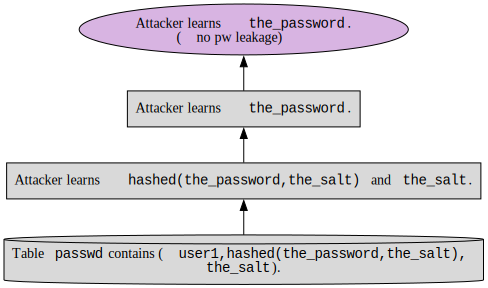

Running ProVerif on: _scenarios/singularized_passwords/rainbow_table_attack+intruder_at_database+intruder_at_singularization_database.pv


### singularized_passwords — rainbow_table_attack+intruder_at_database+intruder_at_singularization_database.pv

- Minimal combo: `Intruder at database, Intruder at singularization database, Rainbow table attack`  
- Costs: `{'time': 100, 'hack': 2}`

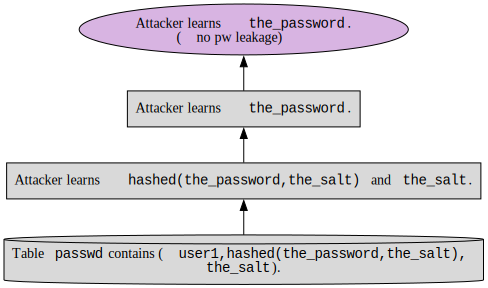

In [4]:
## Attack Trees for `no pw leakage` (rendered inline)

# Render only the derivation tree associated with attacker learning the real password.
# We explicitly exclude hashed-password leakage queries.

from IPython.display import SVG

for item in selected:
    scenario_path = item["scenario"].path
    output = atk.extract(scenario_path, verbose_clauses=True)

    target_derivs = []
    for d in output.derivations:
        q = d.query or ""
        qn = normalize_query(q)
        if "attackerthepassword" in qn and "hashed" not in qn:
            target_derivs.append(d)

    display(Markdown(f"### {item['model']} — {scenario_path.name}"))
    display(Markdown(f"- Minimal combo: `{', '.join(sorted(item['combo']['scenarios'])) or 'base'}`  \n- Costs: `{item['combo']['costs']}`"))

    if not target_derivs:
        print("No derivation found for non-hashed password-leak query in this scenario.")
        continue

    tree = renderer.build_tree_from_derivations(
        target_derivs,
        query_tag=item["query"],
        readable_nodes=True,
        show_clause_ids=False,
    )

    if tree is None:
        print("Could not build tree.")
        continue

    dot = tree.to_graphviz()
    try:
        import graphviz
        src = graphviz.Source(dot, format="svg")
        svg = src.pipe(format="svg").decode("utf-8")
        display(SVG(svg))
    except Exception:
        print("Inline SVG rendering unavailable. Showing DOT snippet:")
        print("\n".join(dot.splitlines()[:20]))